# Baseline - predykcja cen mieszkań w Polsce (regresja)

**Etap 2** projektu ASI. Cel notebooka:
1. **EDA** - rozkłady, braki, skośność targetu, kontrola wycieku (leakage).
2. **Wspólny schemat cech** i inżynieria cech (jedna definicja cech, wspólna z Kedro).
3. **Baseline** - model bazowy + metryka ("liczba do pobicia" w etapie 4).

Strategię danych i modelowania ustaliliśmy po EDA i researchu (typowe pułapki przy
regresji cen nieruchomości). Kluczowe decyzje:
- **Deduplikacja** `keep=last` po `id` (te same ogłoszenia powtarzają się w 11 miesiącach).
- **Split GRUPOWY po `id`** (`GroupShuffleSplit`) - losowy split przeciekłby tożsamość mieszkań.
- **Target `log1p(price)`**, metryki liczone w PLN po `expm1` (cena jest prawostronnie skośna).
- **Natywne kategorie LightGBM** + NaN obsługiwany natywnie (brak nie jest losowy -> niesie sygnał).

> Dane (`training/data/01_raw/`) są poza repozytorium - rozpakuj `archive.zip` (zob. `make data`).

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)

RANDOM_STATE = 42
REFERENCE_YEAR = 2024
np.random.seed(RANDOM_STATE)

## 1. Wczytanie i scalenie danych

Łączymy 11 miesięcznych plików sprzedaży (`apartments_pl_*`). Najem pomijamy.

In [2]:
CANDIDATES = [
    Path("../training/data/01_raw"),
    Path("training/data/01_raw"),
    Path("project/training/data/01_raw"),
]
RAW_DIR = next((p for p in CANDIDATES if p.exists()), None)
assert RAW_DIR is not None, (
    "Nie znaleziono katalogu danych 01_raw (rozpakuj archive.zip)."
)

files = sorted(RAW_DIR.glob("apartments_pl_*.csv"))
parts = []
for f in files:
    d = pd.read_csv(f)
    d["__month"] = f.stem.replace("apartments_pl_", "").replace("_", "-")
    parts.append(d)
raw = pd.concat(parts, ignore_index=True)
print(f"Plików sprzedaży: {len(files)}")
print(f"Wczytano wierszy: {len(raw):,} | unikalnych id: {raw['id'].nunique():,}")
raw.head(3)

Plików sprzedaży: 11
Wczytano wierszy: 195,568 | unikalnych id: 92,967


,id,city,type,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,centreDistance,poiCount,schoolDistance,clinicDistance,postOfficeDistance,kindergartenDistance,restaurantDistance,collegeDistance,pharmacyDistance,ownership,buildingMaterial,condition,hasParkingSpace,hasBalcony,hasElevator,hasSecurity,hasStorageRoom,price,__month
0,f8524536d4b09a0c8ccc0197ec9d7bde,szczecin,blockOfFlats,63.00,3.0,4.0,10.0,1980.0,53.378933,14.625296,6.53,9.0,0.118,1.389,0.628,0.105,1.652,NaN,0.413,condominium,concreteSlab,NaN,yes,yes,yes,no,yes,415000,2023-08
1,accbe77d4b360fea9735f138a50608dd,szczecin,blockOfFlats,36.00,2.0,8.0,10.0,NaN,53.442692,14.559690,2.15,16.0,0.273,0.492,0.652,0.291,0.348,1.404,0.205,cooperative,concreteSlab,NaN,no,yes,yes,no,yes,395995,2023-08
2,8373aa373dbc3fe7ca3b7434166b8766,szczecin,tenement,73.02,3.0,2.0,3.0,NaN,53.452222,14.553333,3.24,9.0,0.275,0.672,0.367,0.246,0.300,1.857,0.280,condominium,brick,NaN,no,no,no,no,no,565000,2023-08


### 1.1 Deduplikacja (keep-last po `id`)

195 568 wierszy, ale tylko ~93 tys. unikalnych mieszkań - to samo ogłoszenie pojawia się
w wielu miesiącach. Zostawiamy **najnowszy** rekord każdego `id` (najświeższa cena rynkowa -
ją serwuje API). Usuwamy też 12 wierszy `ownership='udział'` (artefakt spoza specyfikacji).

In [3]:
df = (
    raw.sort_values(["id", "__month"])
    .drop_duplicates(subset="id", keep="last")
    .reset_index(drop=True)
)
df = df[df["ownership"].isin(["condominium", "cooperative"])].reset_index(drop=True)

assert len(df) == df["id"].nunique(), "Po dedup powinien być 1 wiersz na id"
assert df["price"].between(150_000, 3_250_000).all(), "Cena poza oczekiwanym zakresem"
print(
    f"Po deduplikacji: {len(df):,} mieszkań | cena {int(df.price.min()):,}-{int(df.price.max()):,} PLN"
)

Po deduplikacji: 92,960 mieszkań | cena 150,000-3,250,000 PLN


## 2. EDA

### 2.1 Rozkład targetu - uzasadnienie transformacji `log1p`

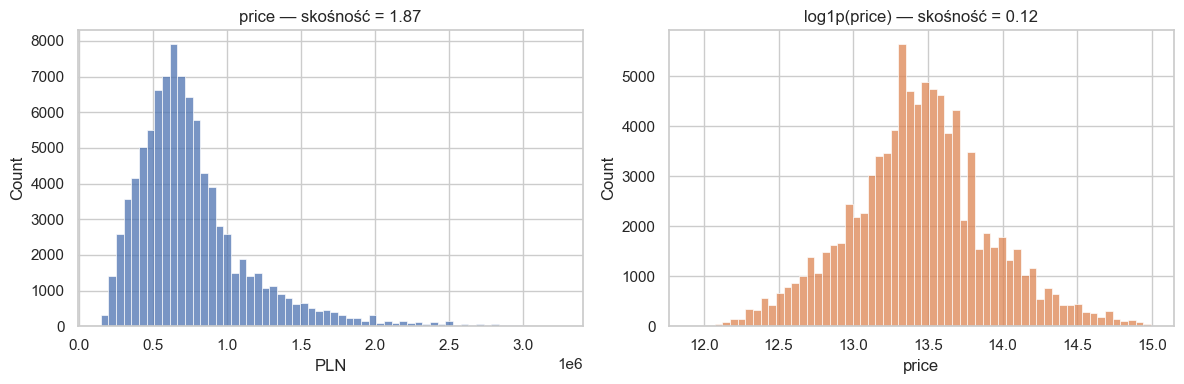

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["price"], bins=60, ax=ax[0])
ax[0].set_title(f"price - skośność = {df['price'].skew():.2f}")
ax[0].set_xlabel("PLN")
sns.histplot(np.log1p(df["price"]), bins=60, ax=ax[1], color="C1")
ax[1].set_title(f"log1p(price) - skośność = {np.log1p(df['price']).skew():.2f}")
plt.tight_layout()
plt.show()

### 2.2 Braki danych

Brak nie jest losowy (np. `condition` podają częściej ogłoszenia premium) - **nie imputujemy naiwnie**, dodajemy flagi `*_is_missing`.

,% braków
condition,75.2
buildingMaterial,42.1
type,21.3
floor,17.2
buildYear,16.7
hasElevator,4.7
collegeDistance,2.7
floorCount,1.1
clinicDistance,0.4
restaurantDistance,0.2


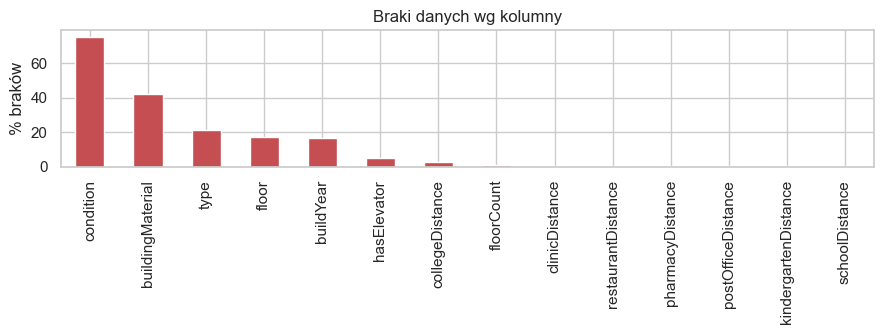

In [5]:
miss = (df.isna().mean() * 100).sort_values(ascending=False)
miss = miss[miss > 0]
display(miss.round(1).to_frame("% braków"))

plt.figure(figsize=(9, 3.5))
miss.plot.bar(color="C3")
plt.ylabel("% braków")
plt.title("Braki danych wg kolumny")
plt.tight_layout()
plt.show()

### 2.3 Geografia i metraż - dwa najsilniejsze czynniki ceny

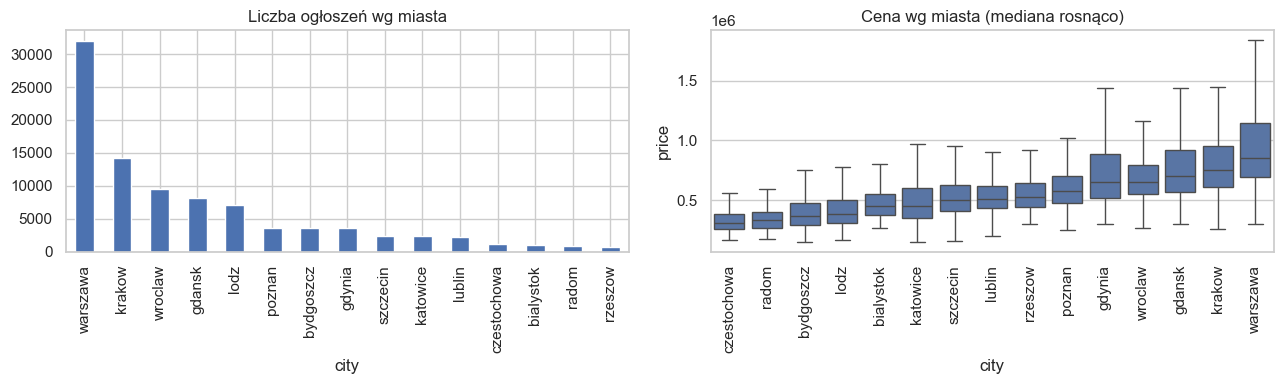

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
df["city"].value_counts().plot.bar(ax=ax[0], color="C0")
ax[0].set_title("Liczba ogłoszeń wg miasta")
order = df.groupby("city")["price"].median().sort_values().index
sns.boxplot(data=df, x="city", y="price", order=order, ax=ax[1], showfliers=False)
ax[1].set_title("Cena wg miasta (mediana rosnąco)")
ax[1].tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

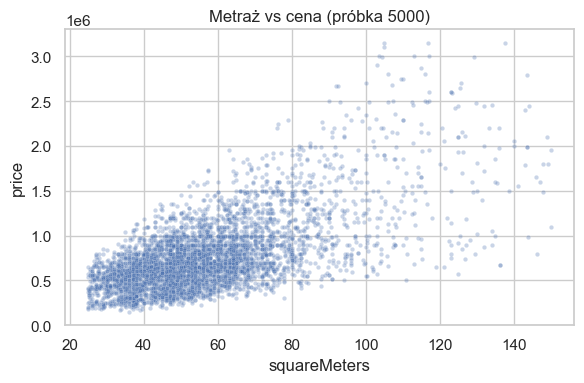

In [7]:
plt.figure(figsize=(6, 4))
sns.scatterplot(
    data=df.sample(5000, random_state=RANDOM_STATE),
    x="squareMeters",
    y="price",
    alpha=0.3,
    s=10,
)
plt.title("Metraż vs cena (próbka 5000)")
plt.tight_layout()
plt.show()

### 2.4 Korelacja cech numerycznych z `log(price)`

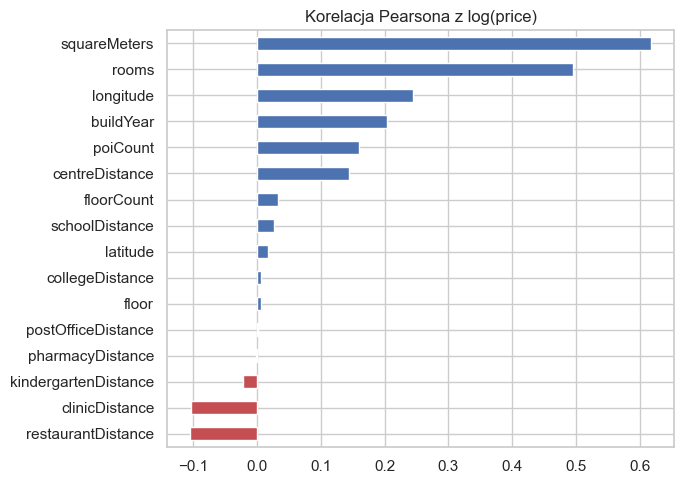

In [8]:
num = df.select_dtypes("number").drop(columns=["price"], errors="ignore")
corr = (
    num.assign(log_price=np.log1p(df["price"]))
    .corr(numeric_only=True)["log_price"]
    .drop("log_price")
    .sort_values()
)
plt.figure(figsize=(7, 5))
corr.plot.barh(color=np.where(corr > 0, "C0", "C3"))
plt.title("Korelacja Pearsona z log(price)")
plt.tight_layout()
plt.show()

### 2.5 Kontrola wycieku (leakage)

Gdyby splitować losowo surowe 195 tys. wierszy, to samo mieszkanie trafiłoby
jednocześnie do treningu i testu -> **sztucznie zawyżone metryki**. Dlatego split jest
**grupowy po `id`** (`GroupShuffleSplit`/`GroupKFold`).

In [9]:
counts = raw["id"].value_counts()
multi = int((counts > 1).sum())
print(
    f"Id w >1 miesiącu: {multi:,} ({multi / raw['id'].nunique() * 100:.1f}% unikalnych)"
)
print(
    "=> losowy split na surowych danych = wyciek tożsamości; stosujemy split grupowy po id."
)

Id w >1 miesiącu: 45,347 (48.8% unikalnych)
=> losowy split na surowych danych = wyciek tożsamości; stosujemy split grupowy po id.


## 3. Inżynieria cech (jeden wspólny kontrakt cech)

Funkcja `build_features` jest **przenoszona 1:1 do pipeline'u Kedro i serwisu FastAPI**
(ta sama funkcja w treningu i serwisie). Odrzucamy `id` (identyfikator), `price` (target) i `__month`
(API go nie zna).

In [10]:
CATEGORICAL = ["city", "type", "ownership", "buildingMaterial", "condition"]
BOOL_COLS = [
    "hasParkingSpace",
    "hasBalcony",
    "hasElevator",
    "hasSecurity",
    "hasStorageRoom",
]
POI_COLS = [
    "schoolDistance",
    "clinicDistance",
    "postOfficeDistance",
    "kindergartenDistance",
    "restaurantDistance",
    "collegeDistance",
    "pharmacyDistance",
]
MISSING_FLAG_COLS = ["floor", "buildYear", "type", "buildingMaterial", "condition"]


def build_features(data: pd.DataFrame) -> pd.DataFrame:
    X = data.copy()
    for c in BOOL_COLS:  # yes/no -> 1/0 (NaN zostaje)
        X[c] = X[c].map({"yes": 1, "no": 0})
    X["age"] = REFERENCE_YEAR - X["buildYear"]
    X["floor_ratio"] = X["floor"] / X["floorCount"]
    X["rooms_per_m2"] = X["rooms"] / X["squareMeters"]
    X["is_top_floor"] = (X["floor"] == X["floorCount"]).astype(int)
    X["is_ground_floor"] = (X["floor"] == 0).astype(int)
    X["min_amenity_dist"] = X[POI_COLS].min(axis=1)
    X["mean_amenity_dist"] = X[POI_COLS].mean(axis=1)
    X["amenity_score"] = X[BOOL_COLS].fillna(0).sum(axis=1)
    for c in MISSING_FLAG_COLS:
        X[f"{c}_is_missing"] = X[c].isna().astype(int)
    for c in CATEGORICAL:  # NA -> "missing", dtype category
        X[c] = X[c].astype("object").where(X[c].notna(), "missing").astype("category")
    return X.drop(columns=["id", "price", "__month"])


y = np.log1p(df["price"])
X = build_features(df)
print(f"Macierz cech: {X.shape[0]:,} × {X.shape[1]} cech")
print("Kategoryczne (natywne LGBM):", CATEGORICAL)
X.dtypes.value_counts()

Macierz cech: 92,960 × 39 cech
Kategoryczne (natywne LGBM): ['city', 'type', 'ownership', 'buildingMaterial', 'condition']


float64     23
int64       11
category     1
category     1
category     1
category     1
category     1
Name: count, dtype: int64

## 4. Podział grupowy po `id` (zapis `test_ids` dla spójności z Kedro)

In [11]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups=df["id"]))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
price_test = df["price"].iloc[test_idx].to_numpy()

assert not (set(df["id"].iloc[train_idx]) & set(df["id"].iloc[test_idx])), "Wyciek id!"
print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,} | brak wspólnych id ✓")

out = RAW_DIR.parent / "05_model_input"
out.mkdir(parents=True, exist_ok=True)
df["id"].iloc[test_idx].to_csv(out / "test_ids.csv", index=False)
print("Zapisano:", out / "test_ids.csv")

Train: 74,368 | Test: 18,592 | brak wspólnych id ✓
Zapisano: ../training/data/05_model_input/test_ids.csv


## 5. Baseline'y i metryki

Wszystkie metryki liczone **w PLN** (po `expm1`) na **grupowym holdoutcie**:
- **RMSE** (główne kryterium), **MAE**, **MAPE [%]**, **R²**.

Trzy poziomy odniesienia: naiwny (`DummyRegressor`), heurystyka domenowa (mediana ceny/m²
per miasto × metraż) oraz **referencyjny LightGBM** (domyślne hiperparametry) - to jego wynik
jest "liczbą do pobicia" w etapie 4.

In [12]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)


def metrics_pln(y_true_pln, y_pred_pln) -> dict:
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true_pln, y_pred_pln)),
        "MAE": mean_absolute_error(y_true_pln, y_pred_pln),
        "MAPE_%": mean_absolute_percentage_error(y_true_pln, y_pred_pln) * 100,
        "R2": r2_score(y_true_pln, y_pred_pln),
    }


results = {}

In [13]:
from sklearn.dummy import DummyRegressor

dummy = DummyRegressor(strategy="median").fit(X_train, y_train)
results["Dummy (mediana)"] = metrics_pln(price_test, np.expm1(dummy.predict(X_test)))
results["Dummy (mediana)"]

{'RMSE': np.float64(402841.12390332087),
 'MAE': 269711.2551097246,
 'MAPE_%': 38.59976289079697,
 'R2': -0.0424301473482418}

In [14]:
# Heurystyka domenowa: mediana ceny/m² per miasto (liczona TYLKO na treningu) × metraż.
ppm2_train = df["price"].iloc[train_idx] / df["squareMeters"].iloc[train_idx]
med_ppm2 = ppm2_train.groupby(df["city"].iloc[train_idx]).median()
global_ppm2 = ppm2_train.median()

pred_heur = (
    df["city"].iloc[test_idx].map(med_ppm2).fillna(global_ppm2).to_numpy()
    * df["squareMeters"].iloc[test_idx].to_numpy()
)
results["Heurystyka ppm²×m²"] = metrics_pln(price_test, pred_heur)
results["Heurystyka ppm²×m²"]

{'RMSE': np.float64(219128.42874952123),
 'MAE': 148079.98044336392,
 'MAPE_%': 18.5293575411486,
 'R2': 0.6915556536714191}

In [15]:
from lightgbm import LGBMRegressor

lgbm = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=RANDOM_STATE,
    verbose=-1,
)
lgbm.fit(X_train, y_train, categorical_feature=CATEGORICAL)
results["LightGBM (domyślny)"] = metrics_pln(price_test, np.expm1(lgbm.predict(X_test)))
results["LightGBM (domyślny)"]

{'RMSE': np.float64(129859.29012680487),
 'MAE': 85287.85836329764,
 'MAPE_%': 10.873514927540807,
 'R2': 0.8916758190812554}

### 6. Porównanie i "liczba do pobicia"

In [16]:
res_df = pd.DataFrame(results).T
display(
    res_df.style.format(
        {"RMSE": "{:,.0f}", "MAE": "{:,.0f}", "MAPE_%": "{:.2f}", "R2": "{:.4f}"}
    )
)

beat = results["LightGBM (domyślny)"]
print("\nLICZBA DO POBICIA (baseline LightGBM, grouped holdout):")
print(
    f"  R²   = {beat['R2']:.4f}   (cel etapu 4: >= 0.85; R² > 0.93 = podejrzenie wycieku)"
)
print(f"  RMSE = {beat['RMSE']:,.0f} PLN")
print(f"  MAE  = {beat['MAE']:,.0f} PLN")
print(f"  MAPE = {beat['MAPE_%']:.2f} %")

,RMSE,MAE,MAPE_%,R2
Dummy (mediana),"402,841","269,711",38.60,-0.0424
Heurystyka ppm²×m²,"219,128","148,080",18.53,0.6916
LightGBM (domyślny),"129,859","85,288",10.87,0.8917



LICZBA DO POBICIA (baseline LightGBM, grouped holdout):
  R²   = 0.8917   (cel etapu 4: >= 0.85; R² > 0.93 = podejrzenie wycieku)
  RMSE = 129,859 PLN
  MAE  = 85,288 PLN
  MAPE = 10.87 %


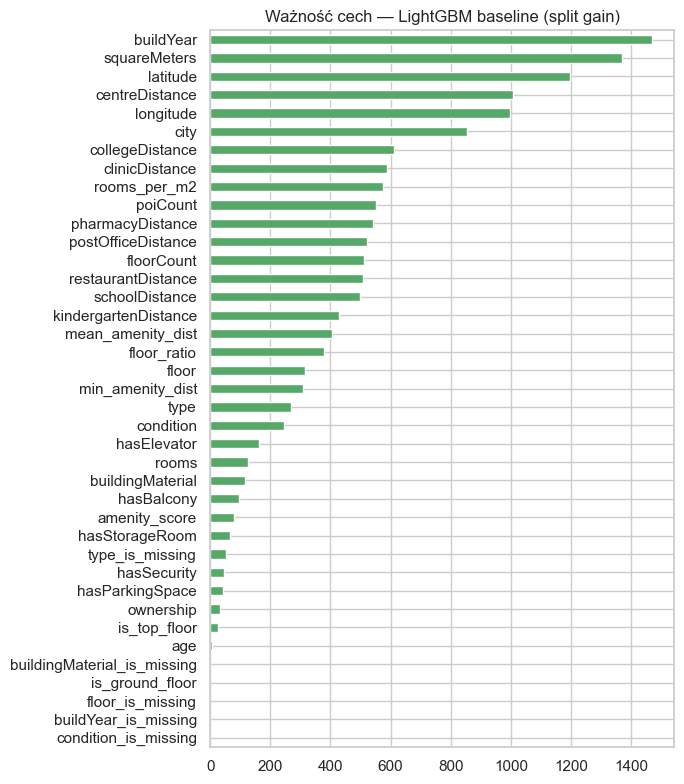

In [17]:
imp = pd.Series(lgbm.feature_importances_, index=X.columns).sort_values()
plt.figure(figsize=(7, 8))
imp.plot.barh(color="C2")
plt.title("Ważność cech - LightGBM baseline (split gain)")
plt.tight_layout()
plt.show()

## 7. Wnioski

- Cena jest silnie prawostronnie skośna -> modelujemy `log1p(price)` (skośność spada do ~0).
- Dominują **metraż** i **lokalizacja** (miasto, `centreDistance`, geo) - zgodnie z intuicją rynkową.
- Split **grupowy po `id`** daje **uczciwą** metrykę (brak wycieku tożsamości mieszkania).
- **Baseline LightGBM** wyznacza liczbę do pobicia; w etapie 4 poprawiamy go przez
  porównanie modeli + **Optuna** (HPO na 5-fold `GroupKFold`), logując do MLflow.
- Funkcja `build_features` i kontrakt cech przechodzą **1:1** do pipeline'u Kedro
  (`data_processing` + `feature_engineering` + `modeling`) i do serwisu FastAPI.